# 00 — Exploración de Datos (EDA)
Análisis inicial de los 6 índices, correlaciones y detección de Index_D.

In [16]:
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.insert(0, ".")
from utils import load_data, INDEX_COLS, find_ghost_source, train_val_split

data = load_data()
train = data["train_indices"][INDEX_COLS]
print(f"Train shape: {train.shape}")
train.describe().round(2)


Train shape: (2347, 6)


,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
count,2347.00,2347.00,2347.00,2347.00,2347.00,2347.00
mean,9005.74,3125.39,15.25,8991.36,86.09,15035.15
std,3917.13,871.75,3.80,3911.55,22.34,16237.48
min,3947.80,1829.08,9.14,3938.07,50.99,178.10
25%,5407.98,2362.90,12.70,5406.73,66.05,1191.20
50%,7640.15,2888.32,13.80,7648.14,80.01,8659.49
75%,12677.25,3971.18,17.26,12654.83,108.03,24940.97
max,16906.80,4796.56,26.57,16869.44,129.33,67566.83


## Detección de valores nulos

In [17]:
# Valores nulos en los índices principales
null_counts = train.isnull().sum()
null_pct = (train.isnull().mean() * 100).round(2)
null_df = pd.DataFrame({"nulos": null_counts, "% nulos": null_pct})
print("=== Valores nulos en train_indices ===")
print(null_df)
print(f"\nTotal filas: {len(train)}  |  Filas con algún nulo: {train.isnull().any(axis=1).sum()}")

# Otras tablas disponibles
for key, df in data.items():
    if isinstance(df, pd.DataFrame) and key != "train_indices":
        n = df.isnull().sum().sum()
        pct = round(float(df.isnull().mean().mean()) * 100, 2)
        print(f"\n{key}: {n} valores nulos ({pct}% del total)")
        if n > 0:
            print(df.isnull().sum()[df.isnull().sum() > 0])

# Heatmap de nulos (solo si hay alguno)
if train.isnull().any().any():
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.imshow(train.isnull().T, aspect="auto", cmap="Reds", interpolation="none")
    ax.set_yticks(range(len(INDEX_COLS)))
    ax.set_yticklabels(INDEX_COLS)
    ax.set_xlabel("Tiempo (índice)")
    ax.set_title("Mapa de valores nulos (rojo = nulo)")
    plt.tight_layout()
    plt.show()
else:
    print("\nNo hay valores nulos en train_indices.")


=== Valores nulos en train_indices ===
         nulos  % nulos
Index_A      0      0.0
Index_B      0      0.0
Index_C      0      0.0
Index_D      0      0.0
Index_E      0      0.0
Index_F      0      0.0

Total filas: 2347  |  Filas con algún nulo: 0

test_dates: 0.0 valores nulos (nan% del total)

train_news: 0 valores nulos (0.0% del total)

train_macro_factors: 0 valores nulos (0.0% del total)

train_network_metrics: 0 valores nulos (0.0% del total)

test_news: 0 valores nulos (0.0% del total)

test_macro_factors: 0 valores nulos (0.0% del total)

test_network_metrics: 0 valores nulos (0.0% del total)

No hay valores nulos en train_indices.


## Evolución temporal de los 6 índices

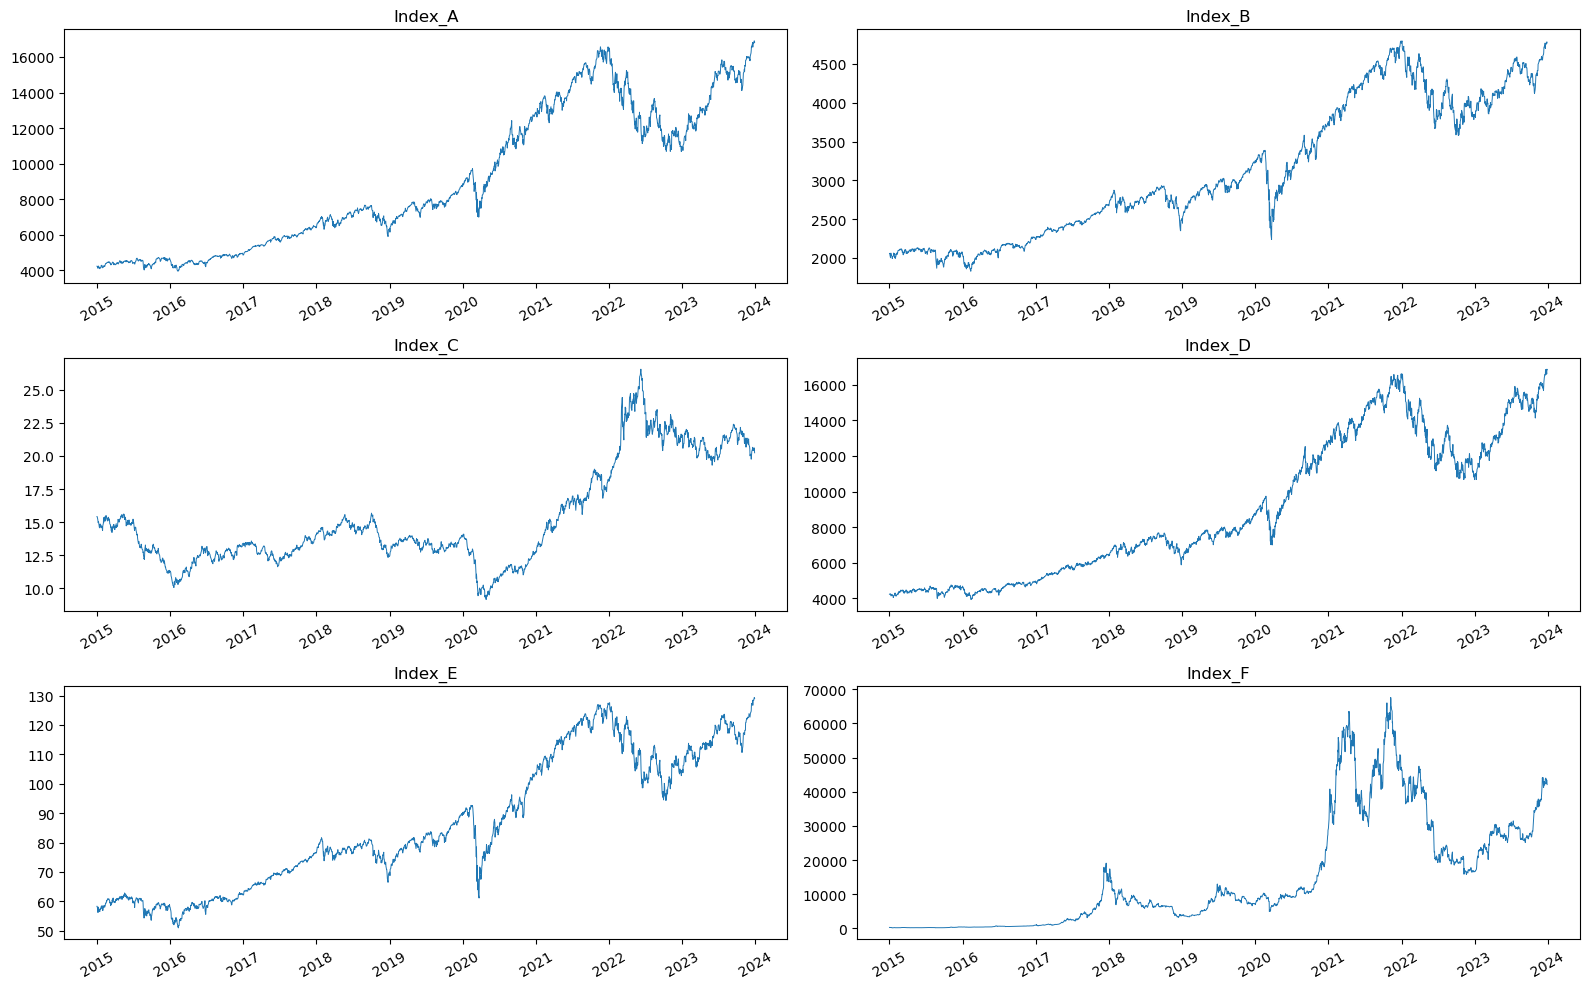

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), INDEX_COLS):
    ax.plot(train.index, train[col], lw=0.7)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("eda_indices.png", dpi=100)
plt.show()


## Matriz de correlación

         Index_A  Index_B  Index_C  Index_D  Index_E  Index_F
Index_A    1.000    0.990    0.672    0.998    0.988    0.901
Index_B    0.990    1.000    0.735    0.988    0.998    0.897
Index_C    0.672    0.735    1.000    0.675    0.723    0.605
Index_D    0.998    0.988    0.675    1.000    0.986    0.901
Index_E    0.988    0.998    0.723    0.986    1.000    0.903
Index_F    0.901    0.897    0.605    0.901    0.903    1.000


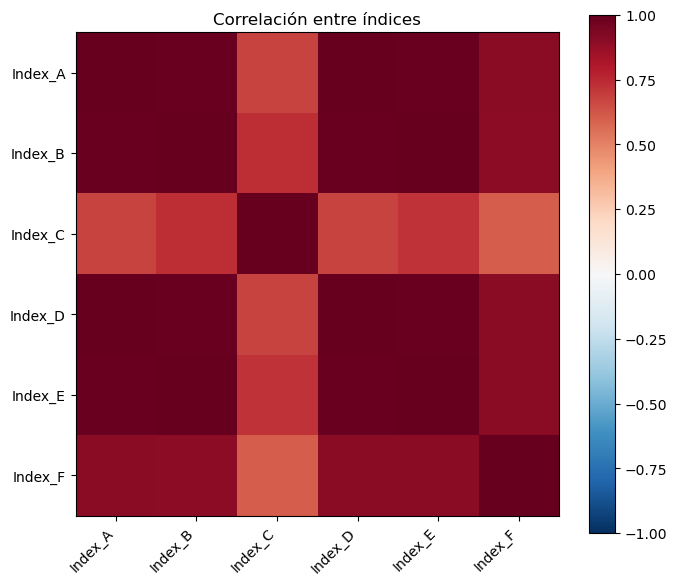

In [19]:
corr = train.corr()
print(corr.round(3))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(INDEX_COLS, rotation=45, ha="right")
ax.set_yticklabels(INDEX_COLS)
plt.colorbar(im, ax=ax)
plt.title("Correlación entre índices")
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=100)
plt.show()


## Detección de Index_D (The Ghost)

In [20]:
source_col, lag, corr_val = find_ghost_source(train, target_col="Index_D", max_lag=30)
print(f"Index_D parece seguir a {source_col} con lag={lag} días (r={corr_val:.4f})")


Ghost source: Index_A at lag 3 (corr=0.9999)
Index_D parece seguir a Index_A con lag=3 días (r=0.9999)


## Estacionariedad (test ADF)

In [21]:
from statsmodels.tsa.stattools import adfuller
print("ADF p-values (< 0.05 → estacionaria):")
for col in INDEX_COLS:
    p = adfuller(train[col].dropna())[1]
    status = "ESTACIONARIA" if p < 0.05 else "no estacionaria"
    print(f"  {col}: p={p:.4f}  {status}")


ADF p-values (< 0.05 → estacionaria):
  Index_A: p=0.9576  no estacionaria
  Index_B: p=0.9144  no estacionaria
  Index_C: p=0.8127  no estacionaria
  Index_D: p=0.9558  no estacionaria
  Index_E: p=0.8840  no estacionaria
  Index_F: p=0.5653  no estacionaria


## Factores macro y métricas de red (Index_F)

In [22]:
if "train_macro_factors" in data:
    print("Macro factors:"); display(data["train_macro_factors"].tail(3))
if "train_network_metrics" in data:
    print("Network metrics:"); display(data["train_network_metrics"].tail(3))


Macro factors:


,Gold,Oil,InterestRate
2023-12-27,2081.899902,74.110001,0.05235
2023-12-28,2073.899902,71.769997,0.05218
2023-12-29,2062.399902,71.650002,0.05180


Network metrics:


,ActiveNodes,TxVolume,HashRate
2023-12-27,295287.528021,1.097407e+15,205.016588
2023-12-28,284214.606192,9.801036e+14,205.909888
2023-12-29,272766.227768,1.094585e+15,205.089230


## Distribución de retornos

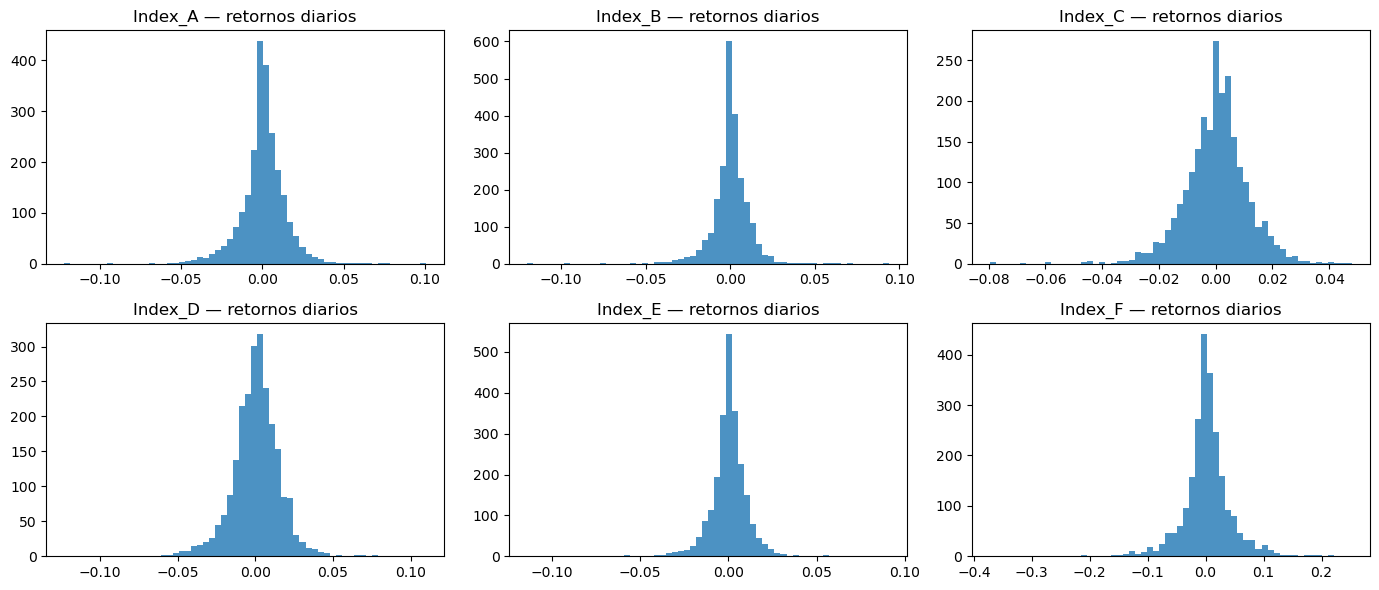

In [23]:
returns = train.pct_change().dropna()
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flatten(), INDEX_COLS):
    ax.hist(returns[col], bins=60, edgecolor="none", alpha=0.8)
    ax.set_title(f"{col} — retornos diarios")
plt.tight_layout()
plt.show()
